In [1]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulate_focused_image(wf_error_to_retrieve,
                          simulation_elements,
                          wavelength):
    """
    Simulate a focused wavefront image using a specified phase error.
    This is not using defocus, and only the abberation we are trying to sense.
    Generates a complex-va
    lued wavefront by applying the provided phase error to the telescope pupil mask,
    and returns the resulting focused intensity image, phase, and full wavefront object.
    Parameters
    ----------
    wf_error_to_retrieve : ndarray
        Phase error to apply to the wavefront (in radians). Should be broadcastable to the pupil shape.
    simulation_elements : dict
        Dictionary containing precomputed simulation components, must include:
            - ‘telescope_pupil’ : ndarray
                Circular pupil aperture mask.
    wavelength : float
        Wavelength of the simulated light, in meters.
    Returns
    -------
    wf_focused_intensity : ndarray
        2D array representing the intensity distribution of the focused wavefront.
    wf_focused_phase : ndarray
        2D array of the phase map of the focused wavefront.
    wf_focused : Wavefront
        The complex-valued wavefront object after applying the phase error.
    Notes
    -----
    - The input phase error is flattened to match the expected format for constructing the Wavefront.
    - Returned intensity is shaped to match the pupil grid and can be used in downstream phase retrieval.
    """
    
    plt.imshow(wf_error_to_retrieve)
    plt.title('wf_error to retrieve in focused image')
    plt.show()
    prop2f = FraunhoferPropagator(simulation_elements['pupil_grid'],
                                    simulation_elements['focal_grid'],
                                    focal_length=seal_parameters['focal_length_meters']
                                    )
    telescope_pupil=simulation_elements['telescope_pupil']
    wf_focused = Wavefront(simulation_elements['telescope_pupil'] * np.exp(1j * wf_error_to_retrieve.ravel()), #or flatten
                   seal_parameters['wavelength_meter'])
    wf_focused= prop2f(wf_focused)
    wf_focused_intensity = wf_focused.intensity
    wf_focused_intensity = resize(wf_focused_intensity,
                                   (seal_parameters['pupil_pixel_dimension'],seal_parameters['pupil_pixel_dimension']))
    wf_focused_phase = wf_focused.phase
    plt.imshow(wf_focused_intensity)
    plt.title('system_truth_inten in focused image')
    plt.show()
    return wf_focused_intensity, wf_focused_phase, wf_focused

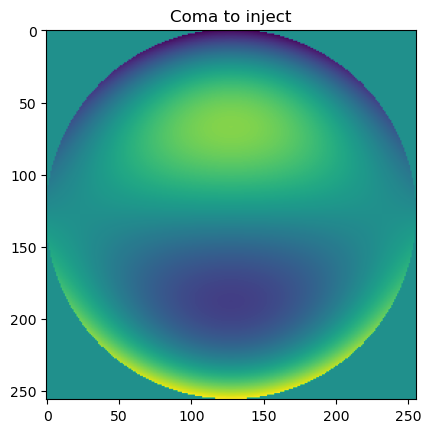

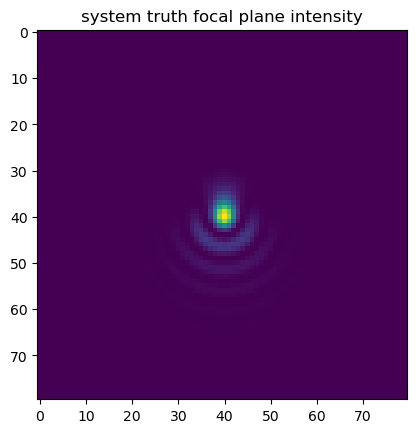

(6400,)
(65536,)


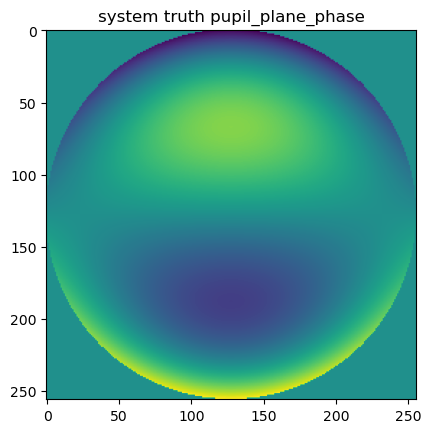

In [5]:
# Breaking down this logic into an example we can test 

# First need to define some optical elements 
pupil_grid = make_pupil_grid(256, 1)
focal_grid = make_focal_grid(4, 10)
prop = FraunhoferPropagator(pupil_grid, focal_grid, 1)
aperture = make_circular_aperture(1)
telescope_pupil = aperture(pupil_grid)

zernikes = make_zernike_basis(10, 1, pupil_grid)
coma = zernikes[6]
wf_error_to_retrieve = coma*0.75
plt.imshow(wf_error_to_retrieve.shaped)
plt.title('Coma to inject')
plt.show()

wf = Wavefront(telescope_pupil * np.exp(1j * wf_error_to_retrieve.ravel()))
wf_focal_plane= prop(wf)
wf_focal_intensity = wf_focal_plane.intensity

# I feel like we are actually going to want the pupil plane phase here? That is what we need to compare ... 
# previous : 
wf_focused_phase = wf_focal_plane.phase
### suggested : 
wf_pupil_phase = wf.phase 
### ALSO there was something funky going on with resizing? you should not need to do that rn 

plt.imshow(wf_focal_intensity.shaped)
plt.title('system truth focal plane intensity')
plt.show()
print(wf_focal_intensity.shape)
print(wf_pupil_phase.shape)
plt.imshow(wf_pupil_phase.shaped)
plt.title('system truth pupil_plane_phase')
plt.show()